In [13]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils

# Assume `run_simulation` is a function that runs your simulation and returns enzyme activity
def run_simulation(start_volume, feed_gap, ramp_factor):
    weibull_values = pd.read_csv('pdfcsv.csv')
    xvalues = weibull_values['x']
    y_values = weibull_values['pdf']

    # Create a cubic spline interpolation model
    cs = CubicSpline(xvalues, y_values)

    initial_volume = start_volume
    flow_volume = initial_volume
    ramp_rate = ramp_factor 

    # Initial conditions
    X0 = config.X0  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = config.MUE_OPT    # U/CDW g
    mu_max = config.MU_MAX   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  feed_gap
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate(S)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0:
                flow_volume *= math.exp(ramp_rate)
                substrate_action = flow_volume
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
    return D[i+1][2]    

exp_num = 0
def objective(trial):
    global exp_num
    exp_num += 1
    # Suggest values for each independent variable
    start_volume = trial.suggest_float('start_volume',0.0001  , 0.0009 )  # Volume in liters
    feed_gap = trial.suggest_float('feed_gap', 0.01 , 0.5  )  # Gap in hours
    ramp_factor = trial.suggest_float('ramp_factor', 0.001 , 0.5)  # Ramp factor

    # Run simulation with suggested values
    enzyme_activity = run_simulation(start_volume, feed_gap, ramp_factor)
    
    # Return enzyme activity as it is the metric we want to maximize
    return enzyme_activity


In [14]:
activities = []
parameters = []
for i in range(20):
    # Create a study and run optimization
    study = optuna.create_study(direction="maximize")  # We want to maximize enzyme activity
    study.optimize(objective, n_trials=125)  # Set the number of trials as needed

    activities.append(study.best_value)
    parameters.append(study.best_params)

print(activities)

[I 2024-12-12 06:59:00,213] A new study created in memory with name: no-name-32d728b1-2407-4dc6-acaf-dd76367f91f3
[I 2024-12-12 06:59:00,227] Trial 0 finished with value: 2.173805133411261 and parameters: {'start_volume': 0.0007309318811075822, 'feed_gap': 0.39683256033433767, 'ramp_factor': 0.2828655465678985}. Best is trial 0 with value: 2.173805133411261.
[I 2024-12-12 06:59:00,276] Trial 1 finished with value: 0.32510821776236326 and parameters: {'start_volume': 0.00010475675043033057, 'feed_gap': 0.4806179841651565, 'ramp_factor': 0.014315999284605037}. Best is trial 0 with value: 2.173805133411261.
[I 2024-12-12 06:59:00,279] Trial 2 finished with value: 0.0017707883874957975 and parameters: {'start_volume': 0.0008961539687061512, 'feed_gap': 0.04012572296574909, 'ramp_factor': 0.27619160619619304}. Best is trial 0 with value: 2.173805133411261.
[I 2024-12-12 06:59:00,289] Trial 3 finished with value: 1.2314373718420955 and parameters: {'start_volume': 0.0005780341261794005, 'fee

[3.2133056573837617, 3.052752409230732, 3.10747019383611, 2.999524269181894, 3.0799536367080544, 2.8981462440340438, 3.0558815284898437, 3.137797945537878, 2.9927716649064897, 3.0419257132692006, 3.042071061069636, 2.901497534409894, 3.039235572110736, 3.099249330174812, 3.1995451246023547, 3.12279635328889, 2.8186784860186003, 3.0280119139058606, 3.111018195001904, 3.063930912360133]


In [15]:
indx = activities.index(max(activities))
best_parameters = parameters[indx]
print(best_parameters)
print(max(activities))

{'start_volume': 0.000785972404073766, 'feed_gap': 0.1701723516353244, 'ramp_factor': 0.0739859459733378}
3.2133056573837617


In [16]:
best_params = best_parameters
best_start_volume = best_params['start_volume']
best_feed_gap = best_params['feed_gap']
best_ramp_factor = best_params['ramp_factor']

# Run final simulation with the best parameters, if needed
best_enzyme_activity = run_simulation(best_start_volume, best_feed_gap, best_ramp_factor)

print(f"Best Starting volume: {best_start_volume}")
print(f"Best Feeding Interval: {best_feed_gap}")
print(f"Best Ramp Factor: {best_ramp_factor}")
print("Enzyme activity with best parameters:", best_enzyme_activity)


Best Starting volume: 0.000785972404073766
Best Feeding Interval: 0.1701723516353244
Best Ramp Factor: 0.0739859459733378
Enzyme activity with best parameters: 3.2133056573837617


Start flow volume 0.000785972404073766
Feed Interval 0.1701723516353244
Ramp Factor 0.0739859459733378
 -----------------------------------------------------------------------
 ----------------------------  Results  --------------------------------
 MAX ENZYME ACTIVITY :  3.2133056573837617


<Figure size 700x500 with 0 Axes>

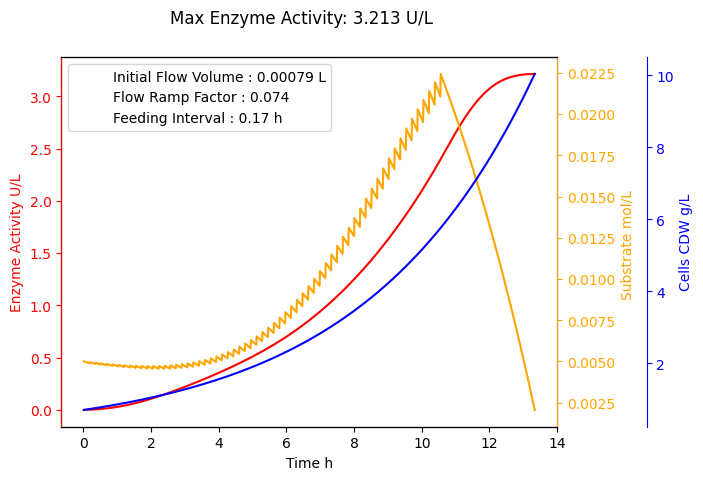

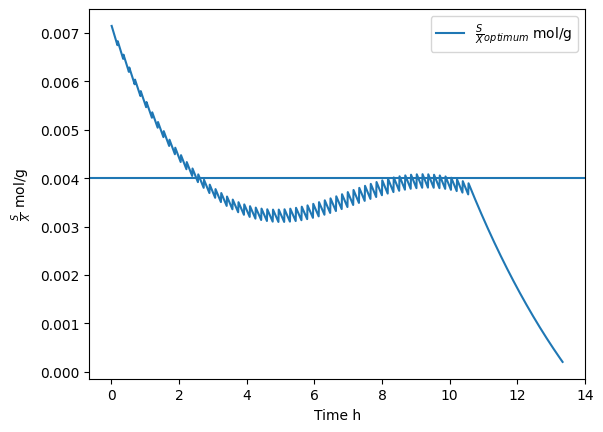

In [17]:
from matplotlib.lines import Line2D

start_flow_volume = best_start_volume
feed_interval = best_feed_gap
ramp_factor = best_ramp_factor

#print(f"------------- Experiment {index+1} ------------")
print(f"Start flow volume {start_flow_volume}")
print(f"Feed Interval {feed_interval}")
print(f"Ramp Factor {ramp_factor}")

weibull_values = pd.read_csv('pdfcsv.csv')
xvalues = weibull_values['x']
y_values = weibull_values['pdf']

# Create a cubic spline interpolation model
cs = CubicSpline(xvalues, y_values)

initial_volume = start_flow_volume
flow_volume = initial_volume
ramp_rate = ramp_factor

# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  feed_interval # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0

for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    MuX = utils.cell_growth_rate(S)
    # new cells that are generated
    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX
    
    # Find change in substrate
    delS = dSdt * del_t

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            flow_volume *= math.exp(ramp_rate)
            substrate_action = flow_volume
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = S
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                S = substrate_concentration

    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t
    
    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break


X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
MUE = D[:,5][0:i]
S_C_R = S/X
plt.figure(figsize=(7,5))
max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)
print(" -----------------------------------------------------------------------")
print(" ----------------------------  Results  --------------------------------")
print(" MAX ENZYME ACTIVITY : ", max(D[:,2]))

fig, ax1 = plt.subplots()
fig.suptitle(f"Max Enzyme Activity: {max_enzyme} U/L" )
#fig.suptitle(f"Simulation: Fed Batch Mode")
ax1.plot(tvec[0:i] ,E ,color="red", label= "Enzyme Activity U/L")

ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S, color="orange", label="Substrate mol/L")

ax3 = ax1.twinx()
ax3.plot(tvec[0:i] , X ,color="blue", label="Cells CDW g/L")
#ax3.spines['right'].set_position(('outward',60))
ax3.spines['right'].set_position(('axes',1.18))

ax1.set_ylabel("Enzyme Activity U/L", color="red")
ax1.set_xlabel("Time h")
ax2.set_ylabel("Substrate mol/L ", color="orange")
ax3.set_ylabel("Cells CDW g/L", color="blue")

ax1.tick_params(axis='y',colors="red")
ax2.tick_params(axis='y',colors="orange")
ax3.tick_params(axis='y',colors="blue")

ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")
custom_lines = [
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=f'Initial Flow Volume : {round(start_flow_volume,5)} L'),
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=f'Flow Ramp Factor : {round(ramp_factor,3)}'),
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=f'Feeding Interval : {round(feed_interval,3)} h'),

]

# Add the custom legend
plt.legend(handles=custom_lines)
plt.show()

plt.plot(tvec[:len(S_C_R)], S_C_R, label=r"$\frac{S}{X}_{optimum}$ mol/g")
plt.axhline(y=config.OPT_SUB_CELL_RATIO)
plt.xlabel("Time h")
plt.ylabel(r"$\frac{S}{X}$ mol/g")
plt.legend()

# Perturbation Experiments

In [32]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils

# Assume `run_simulation` is a function that runs your simulation and returns enzyme activity
def run_simulation(start_volume, feed_gap, ramp_factor, X0, mux):
    weibull_values = pd.read_csv('pdfcsv.csv')
    xvalues = weibull_values['x']
    y_values = weibull_values['pdf']

    # Create a cubic spline interpolation model
    cs = CubicSpline(xvalues, y_values)

    initial_volume = start_volume
    flow_volume = initial_volume
    ramp_rate = ramp_factor 

    # Initial conditions
    X0 = X0  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = config.MUE_OPT    # U/CDW g
    mu_max = mux  # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  feed_gap
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate_test(S,mu_max)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0:
                flow_volume *= math.exp(ramp_rate)
                substrate_action = flow_volume
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
    return D[i+1][2]

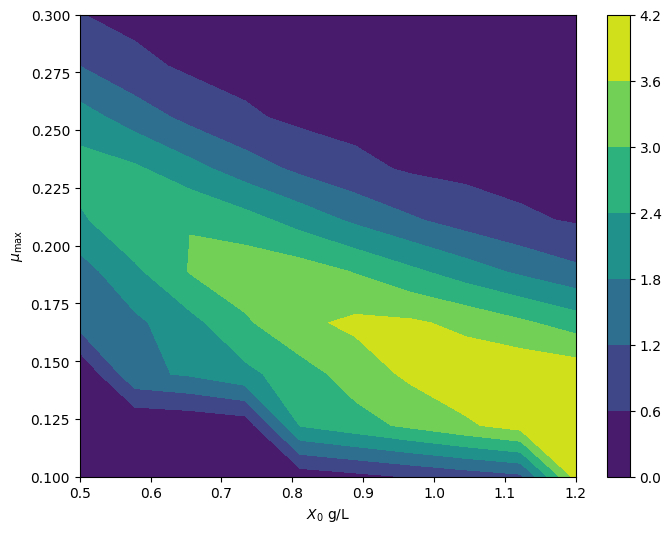

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Define the input data
initial_cell_concs = np.linspace(0.5, 1.2 , 10)  # X-axis: Initial Cell Concentrations
muX_concs = np.linspace(0.1, 0.3, 10)  # Y-axis: Mu Max Values

[X, Y] = np.meshgrid(initial_cell_concs, muX_concs)

Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i,j] = run_simulation(
            0.0008940234401919025, 
            0.1668597235239694,
            0.06416817479783203,
            X[i, j],  # Pass single value from X
            Y[i, j]   # Pass single value from Y
        )

# Create the contour plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
contour = ax.contourf(X, Y, Z, cmap="viridis")  # Change colormap if desired
plt.colorbar(contour, ax=ax)  # Add a colorbar for reference

# Add plot labels and title
ax.set_xlabel(r'$X_0$ g/L')
ax.set_ylabel(r'$\mu_{{\mathrm{max}}}$')

plt.show()




In [34]:
run_simulation(0.0008892908583470567, 0.15295954782159268, 0.05983974644980618 , 1.2, 0.125)

np.float64(4.162445256444332)

C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_18388\913994801.py:110: RuntimeWarning: divide by zero encountered in scalar divide
  sub_cell_ratio = (S/X) * 1e6
C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_18388\913994801.py:110: RuntimeWarning: divide by zero encountered in scalar divide
  sub_cell_ratio = (S/X) * 1e6
C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_18388\913994801.py:110: RuntimeWarning: divide by zero encountered in scalar divide
  sub_cell_ratio = (S/X) * 1e6
C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_18388\913994801.py:110: RuntimeWarning: divide by zero encountered in scalar divide
  sub_cell_ratio = (S/X) * 1e6
C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_18388\913994801.py:110: RuntimeWarning: divide by zero encountered in scalar divide
  sub_cell_ratio = (S/X) * 1e6
C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_18388\913994801.py:110: RuntimeWarning: divide by zero encountered in scalar divide
  sub_cell_ratio = (S/X) * 1e6
C:\Users\R

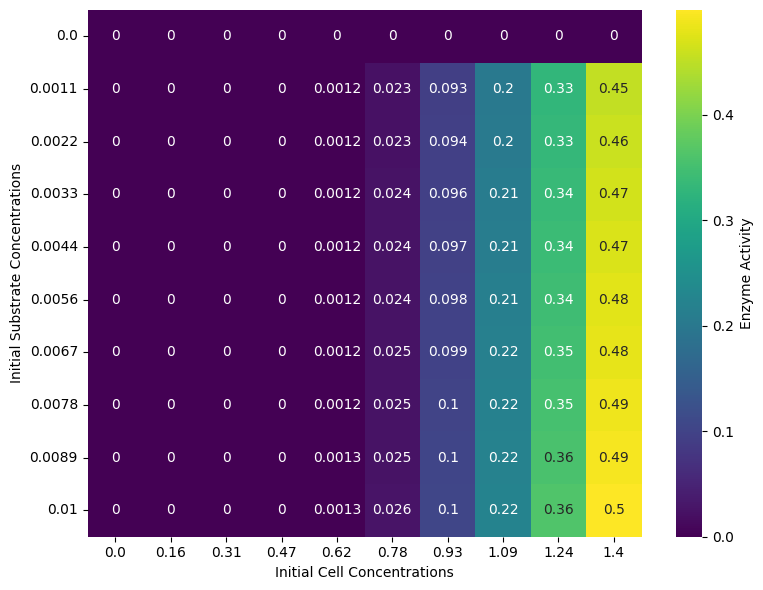

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the input data
initial_cell_concs = np.linspace(0, 1.4, 10)  # X-axis: Initial Cell Concentrations
initial_sub_concs = np.linspace(0, 0.01, 10)  # Y-axis: Mu Max Values

[X, Y] = np.meshgrid(initial_cell_concs, initial_sub_concs)

Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i,j] = run_simulation(
            0.0008892908583470567, 
            0.15295954782159268,
            0.05983974644980618,
            X[i, j],  # Pass single value from X
            Y[i, j]   # Pass single value from Y
        )

# Create a heatmap using Seaborn
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(Z, 
            xticklabels=np.round(initial_cell_concs, 2), 
            yticklabels=np.round(initial_sub_concs, 4), 
            cmap='viridis', 
            cbar_kws={'label': 'Enzyme Activity'},
            annot=True,
            ax=ax)

# Add labels and title
ax.set_xlabel('Initial Cell Concentrations')
ax.set_ylabel('Initial Substrate Concentrations')

plt.tight_layout()
plt.show()

# RL control

In [38]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC, DDPG


# Assume `run_simulation` is a function that runs your simulation and returns enzyme activity
def run_rl_simulation(start_volume, feed_gap, ramp_factor, X0, mux):

    experiment_name = "sac_c10n1_x0mux_2"
    experiment_folder = os.path.join("experiments",experiment_name)
    best_model_folder = os.path.join(experiment_folder, "model" )
    best_model_path = os.path.join(best_model_folder, "best_model.zip")

    if 'ppo' in experiment_name:
        loaded_model = PPO.load(best_model_path)
    elif 'sac' in experiment_name:
        loaded_model = SAC.load(best_model_path)
    elif 'ddpg' in experiment_name:
        loaded_model = DDPG.load(best_model_path)

    weibull_values = pd.read_csv('pdfcsv.csv')
    xvalues = weibull_values['x']
    y_values = weibull_values['pdf']

    # Create a cubic spline interpolation model
    cs = CubicSpline(xvalues, y_values)

    initial_volume = start_volume
    flow_volume = initial_volume
    ramp_rate = ramp_factor 

    # Initial conditions
    X0 = X0  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = config.MUE_OPT    # U/CDW g
    mu_max = mux   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  config.MEDIA_TRANSFER_GAP
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate_test(S,mu_max)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0: 
                model_input = np.array([i, E, X])
                action = loaded_model.predict(model_input, deterministic=False)
                substrate_action = action[0][0]
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
    return D[i+1][2]

In [39]:
run_rl_simulation(0 , 0 ,0 , 0.75, 0.1)

np.float64(3.857947464802165)

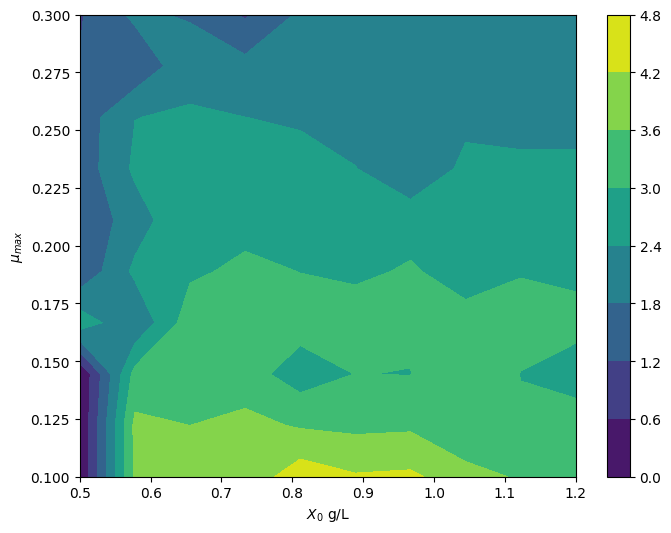

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Define the input data
initial_cell_concs = np.linspace(0.5, 1.2, 10)  # X-axis: Initial Cell Concentrations
muX_concs = np.linspace(0.1, 0.3, 10)  # Y-axis: Mu Max Values

[X, Y] = np.meshgrid(initial_cell_concs, muX_concs)

Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i,j] = run_rl_simulation(
            0, 
            0,
            0,
            X[i, j],  # Pass single value from X
            Y[i, j]   # Pass single value from Y
        )

# Create the contour plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
contour = ax.contourf(X, Y, Z, cmap="viridis")  # Change colormap if desired
plt.colorbar(contour, ax=ax)  # Add a colorbar for reference

# Add plot labels and title
ax.set_xlabel(r'$X_0$ g/L')
ax.set_ylabel(r'$\mu_{max}$')

plt.show()

C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_18388\436510351.py:127: RuntimeWarning: divide by zero encountered in scalar divide
  sub_cell_ratio = (S/X) * 1e6
C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_18388\436510351.py:127: RuntimeWarning: divide by zero encountered in scalar divide
  sub_cell_ratio = (S/X) * 1e6
C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_18388\436510351.py:127: RuntimeWarning: divide by zero encountered in scalar divide
  sub_cell_ratio = (S/X) * 1e6
C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_18388\436510351.py:127: RuntimeWarning: divide by zero encountered in scalar divide
  sub_cell_ratio = (S/X) * 1e6
C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_18388\436510351.py:127: RuntimeWarning: divide by zero encountered in scalar divide
  sub_cell_ratio = (S/X) * 1e6
C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_18388\436510351.py:127: RuntimeWarning: divide by zero encountered in scalar divide
  sub_cell_ratio = (S/X) * 1e6
C:\Users\R

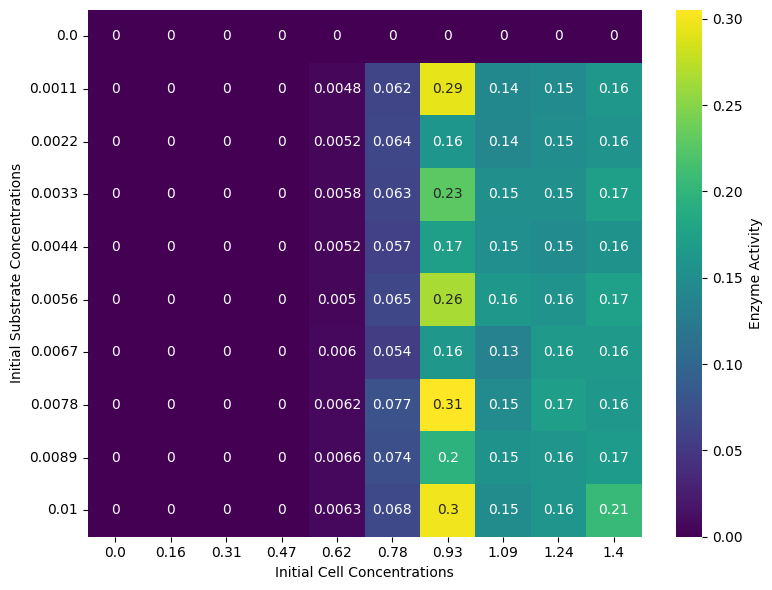

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the input data
initial_cell_concs = np.linspace(0, 1.4, 10)  # X-axis: Initial Cell Concentrations
initial_sub_concs = np.linspace(0, 0.01, 10)  # Y-axis: Mu Max Values

[X, Y] = np.meshgrid(initial_cell_concs, initial_sub_concs)

Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i,j] = run_rl_simulation(
            0.0008892908583470567, 
            0.15295954782159268,
            0.05983974644980618,
            X[i, j],  # Pass single value from X
            Y[i, j]   # Pass single value from Y
        )

# Create a heatmap using Seaborn
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(Z, 
            xticklabels=np.round(initial_cell_concs, 2), 
            yticklabels=np.round(initial_sub_concs, 4), 
            cmap='viridis', 
            cbar_kws={'label': 'Enzyme Activity'},
            annot=True,
            ax=ax)

# Add labels and title
ax.set_xlabel('Initial Cell Concentrations')
ax.set_ylabel('Initial Substrate Concentrations')

plt.tight_layout()
plt.show()


# BayesOpt change in cell rate VS change in enzyme rate

In [26]:
import optuna
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils

# Assume `run_simulation` is a function that runs your simulation and returns enzyme activity
def run_simulation(start_volume, feed_gap, ramp_factor, mu_max, mue):
    weibull_values = pd.read_csv('pdfcsv.csv')
    xvalues = weibull_values['x']
    y_values = weibull_values['pdf']

    # Create a cubic spline interpolation model
    cs = CubicSpline(xvalues, y_values)

    initial_volume = start_volume
    flow_volume = initial_volume
    ramp_rate = ramp_factor 

    # Initial conditions
    X0 = config.X0  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = mue   # U/CDW g
    mu_max = mu_max   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  feed_gap
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0

    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate_test(S, mu_max)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0:
                flow_volume *= math.exp(ramp_rate)
                substrate_action = flow_volume
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.enzyme_production_rate(sub_cell_ratio, cs)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
    return D[i+1][2]

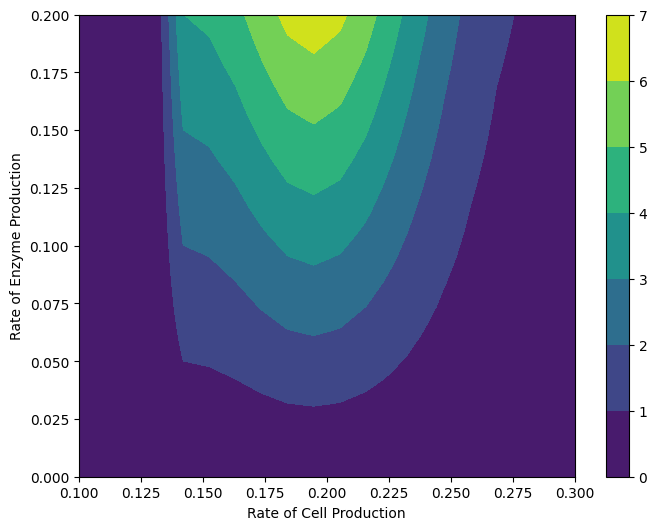

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Define the input data
cell_prod_rates = np.linspace(0.1, 0.3, 20)  # X-axis: Initial Cell Concentrations
enzyme_prod_rates = np.linspace(0, 0.2, 20)  # Y-axis: Mu Max Values

[X, Y] = np.meshgrid(cell_prod_rates, enzyme_prod_rates)

Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i,j] = run_simulation(
            0.0008892908583470567, 
            0.15295954782159268,
            0.05983974644980618,
            X[i, j],  # Pass single value from X
            Y[i, j]   # Pass single value from Y
        )

# Create the contour plot
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
contour = ax.contourf(X, Y, Z, cmap="viridis")  # Change colormap if desired
plt.colorbar(contour, ax=ax)  # Add a colorbar for reference

# Add plot labels and title
ax.set_xlabel('Rate of Cell Production')
ax.set_ylabel('Rate of Enzyme Production')

plt.show()




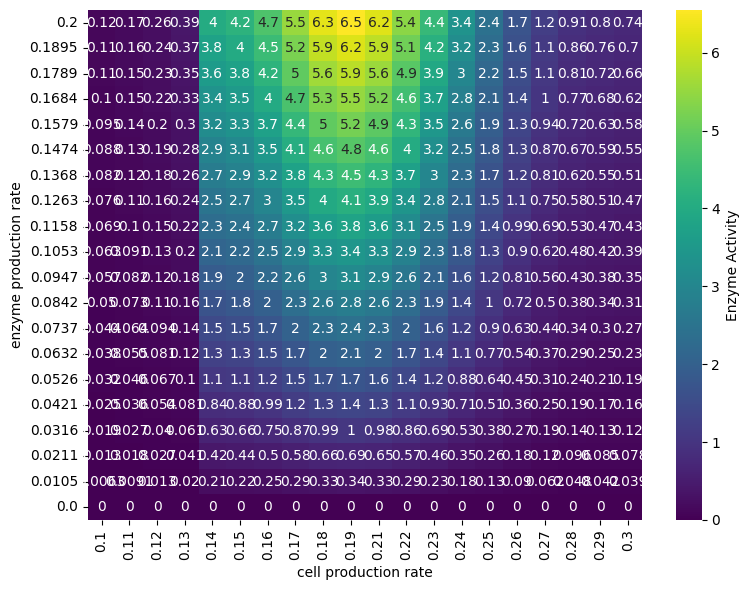

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the input data
cell_prod_rates = np.linspace(0.1, 0.3, 20)  # X-axis: Initial Cell Concentrations
enzyme_prod_rates = np.linspace(0, 0.2, 20)  # Y-axis: Mu Max Values

[X, Y] = np.meshgrid(cell_prod_rates, enzyme_prod_rates)

Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i,j] = run_simulation(
            0.0008892908583470567, 
            0.15295954782159268,
            0.05983974644980618,
            X[i, j],  # Pass single value from X
            Y[i, j]   # Pass single value from Y
        )

# Create a heatmap using Seaborn
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(Z, 
            xticklabels=np.round(cell_prod_rates, 2), 
            yticklabels=np.round(enzyme_prod_rates, 4), 
            cmap='viridis', 
            cbar_kws={'label': 'Enzyme Activity'},
            annot=True,
            ax=ax)

# Add labels and title
ax.set_xlabel('cell production rate')
ax.set_ylabel('enzyme production rate')
ax.invert_yaxis()
plt.tight_layout()
plt.show()